<a href="https://colab.research.google.com/github/YashodipYP/MajorProject_ML/blob/main/MajorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

Loading Dataset


In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
print(df.head(5))

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


Handling Missing Values

In [ ]:
print("\nNull counts per column:")
print(df.isnull().sum())


Null counts per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace('?', np.nan)

In [ ]:
missing_total = df.isnull().sum().sum()
if missing_total > 0:
    print(f"\nFound {missing_total} missing values. Dropping rows with missing data to keep it clean...")
    df = df.dropna()
else:
    print("\nNo explicit missing values found.")


No explicit missing values found.


logical data

In [ ]:
invalid_bps = (df['trestbps'] == 0).sum()
invalid_chol = (df['chol'] == 0).sum()

In [ ]:
print(f"\nRows with 0 Resting Blood Pressure: {invalid_bps}")
print(f"Rows with 0 Cholesterol: {invalid_chol}")


Rows with 0 Resting Blood Pressure: 0
Rows with 0 Cholesterol: 0


Replacing them with the median of that specific feature

In [ ]:
if invalid_bps > 0:
    df['trestbps'] = df['trestbps'].replace(0, df['trestbps'].median())
if invalid_chol > 0:
    df['chol'] = df['chol'].replace(0, df['chol'].median())

Categorical Feature Formatting

In [ ]:
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print("\nUnique values in categorical columns:")
for col in categorical_columns:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")


Unique values in categorical columns:
sex: [1 0]
cp: [3 2 1 0]
fbs: [1 0]
restecg: [0 1 2]
exang: [0 1]
slope: [0 2 1]
ca: [0 2 1 3 4]
thal: [1 2 3 0]


In [ ]:
if 'num' in df.columns and 'target' not in df.columns:
    df = df.rename(columns={'num': 'target'})

Ensuring the target is strictly 0 or 1

In [ ]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
print("\nFinal clean dataset breakdown:")
print(df['target'].value_counts())


Final clean dataset breakdown:
target
1    165
0    138
Name: count, dtype: int64


In [ ]:
df.to_csv("cleaned_heart_data.csv", index=False)
print("\nData cleaning complete! Cleaned dataset saved as 'cleaned_heart_data.csv'.")


Data cleaning complete! Cleaned dataset saved as 'cleaned_heart_data.csv'.


EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv("cleaned_heart_data.csv")

Target Variable Distribution

/tmp/ipykernel_1837/3194105386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette='Set2')


Text(0, 0.5, 'Count')

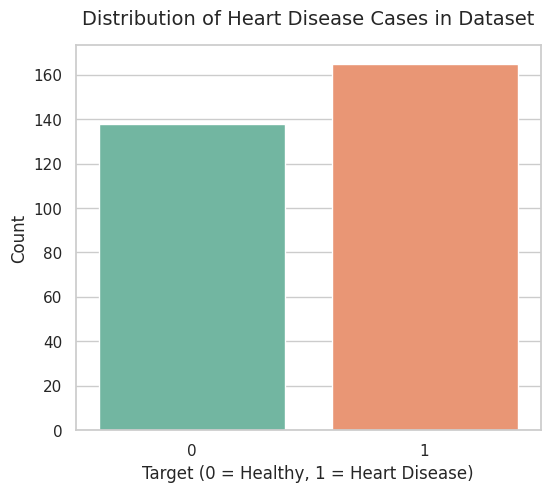

In [ ]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution of Heart Disease Cases in Dataset', fontsize=14, pad=15)
plt.xlabel('Target (0 = Healthy, 1 = Heart Disease)', fontsize=12)
plt.ylabel('Count', fontsize=12)

Adding exact count labels on top of the bars

In [ ]:
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=300)
plt.show()

<Figure size 1000x600 with 0 Axes>

Correlation Matrix Heatmap

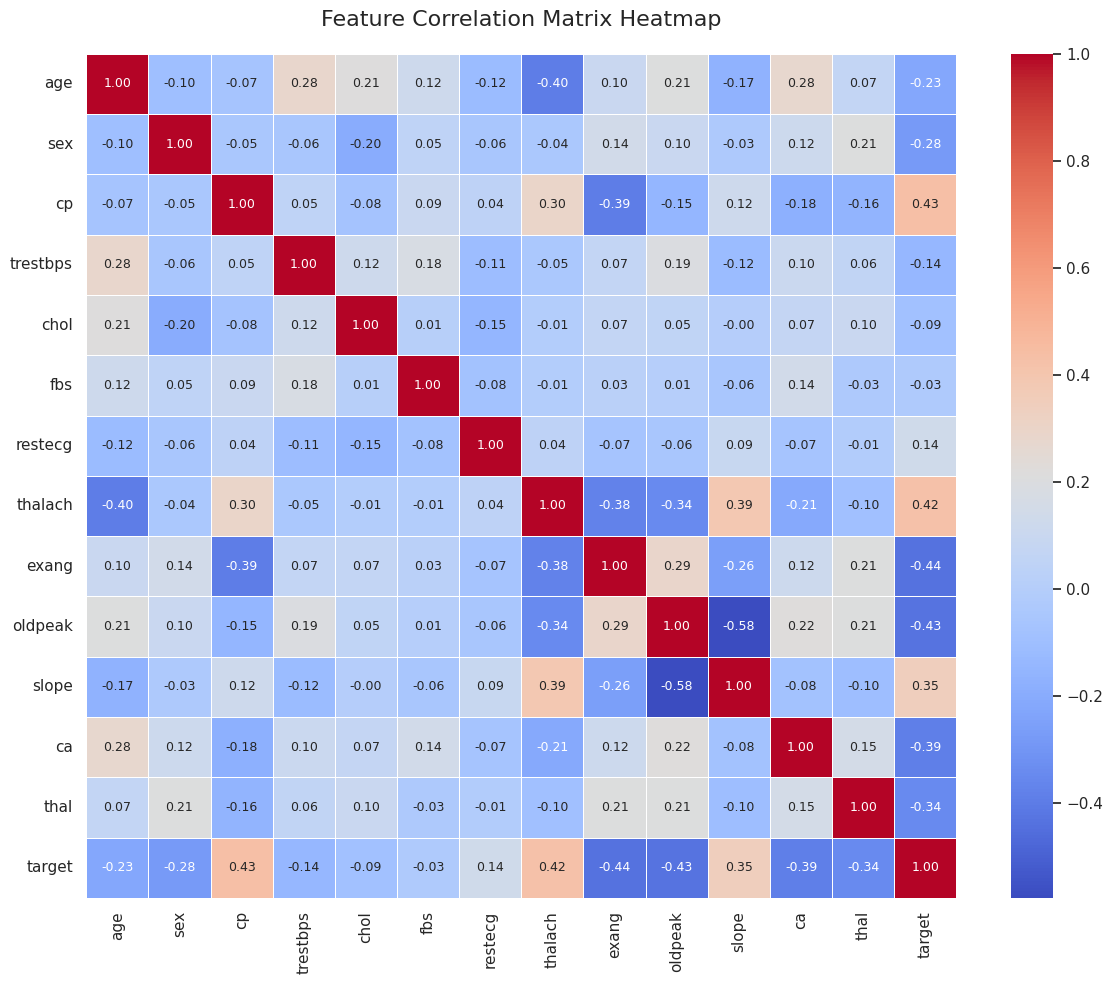

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Feature Correlation Matrix Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300)
plt.show()

In [ ]:
print("\nTop features correlated with Heart Disease:")
print(correlation_matrix['target'].sort_values(ascending=False))


Top features correlated with Heart Disease:
target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64


Age Distribution vs Target

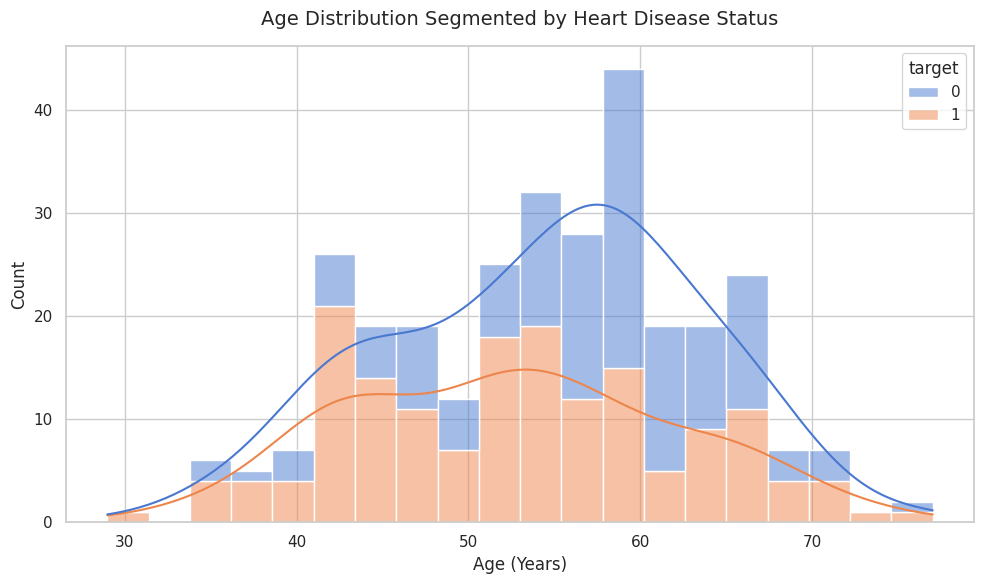

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', multiple='stack', kde=True, palette='muted', bins=20)
plt.title('Age Distribution Segmented by Heart Disease Status', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('eda_age_vs_target.png', dpi=300)
plt.show()

Chest Pain Type vs Target

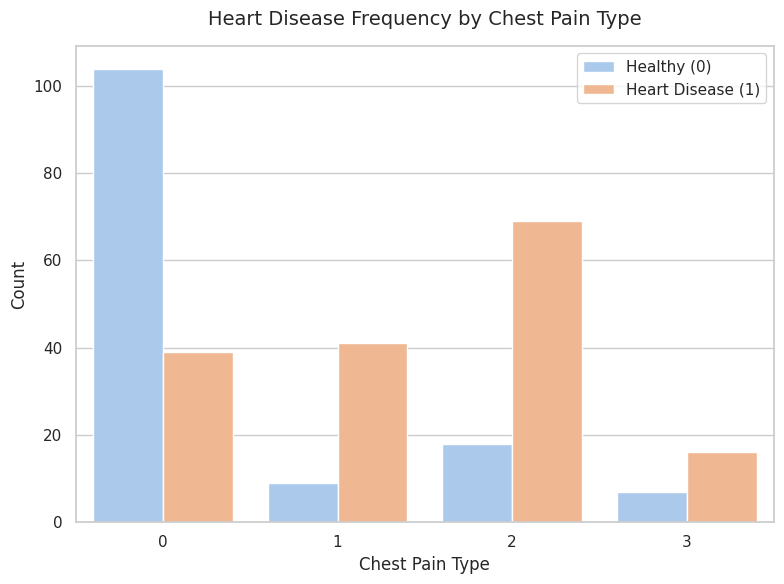

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='cp', hue='target', data=df, palette='pastel')
plt.title('Heart Disease Frequency by Chest Pain Type', fontsize=14, pad=15)
plt.xlabel('Chest Pain Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Healthy (0)', 'Heart Disease (1)'], loc='upper right')
plt.tight_layout()
plt.savefig('eda_chest_pain_vs_target.png', dpi=300)
plt.show()

Feature Engineering & Model Building

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv("cleaned_heart_data.csv")

Splitting Features and Target

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Split data into Train and Test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training feature matrix shape: {X_train.shape}")
print(f"Testing feature matrix shape: {X_test.shape}")

Training feature matrix shape: (242, 13)
Testing feature matrix shape: (61, 13)


Data Transformation Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features) ])

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

AI Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
tf.random.set_seed(42)

Network Architecture

In [ ]:
input_dim = X_train_processed.shape[1]

inputs = Input(shape=(input_dim,))
x = Dense(32, activation='relu')(inputs)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(1, activation='sigmoid')(x)

In [ ]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',  metrics=['accuracy'])

Model Training

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Training the Artificial Neural Network ---")
history = nn_model.fit(X_train_processed, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stop],verbose=1
)


--- Training the Artificial Neural Network ---
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6114 - loss: 0.6533 - val_accuracy: 0.7347 - val_loss: 0.5622
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6891 - loss: 0.5929 - val_accuracy: 0.7755 - val_loss: 0.5286
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6943 - loss: 0.5936 - val_accuracy: 0.7959 - val_loss: 0.4997
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7150 - loss: 0.5790 - val_accuracy: 0.8163 - val_loss: 0.4744
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7565 - loss: 0.5575 - val_accuracy: 0.8163 - val_loss: 0.4506
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7461 - loss: 0.5349 - val_accuracy: 0.8163 - val_loss: 0.4318
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7720 - loss: 0.5272 - val_accuracy: 0.8163 - val_loss: 0.4191
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.

Model Evaluation and Performance Comparison Matrix

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)])

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
grid_log = GridSearchCV(log_reg, {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}, cv=5, scoring='accuracy', n_jobs=-1)
grid_log.fit(X_train_processed, y_train)

dt_clf = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt_clf, {'max_depth': [3, 5, 7, 10], 'criterion': ['gini', 'entropy']}, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_processed, y_train)

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), {'n_estimators': [50, 100, 200], 'max_depth': [4, 6, 8, 10]}, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

Compiling everything

In [ ]:
models = {'Logistic Regression': grid_log.best_estimator_,'Decision Tree': grid_dt.best_estimator_,'Random Forest': grid_rf.best_estimator_}
evaluation_results = {}

In [ ]:
for name, model in models.items():
    predictions = model.predict(X_test_processed)
    probabilities = model.predict_proba(X_test_processed)[:, 1]

    evaluation_results[name] = {
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1-Score': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, probabilities)
    }

In [ ]:
try:
    nn_probabilities = nn_model.predict(X_test_processed).flatten()
    nn_predictions = (nn_probabilities > 0.5).astype(int)

    evaluation_results['Neural Network'] = {
        'Accuracy': accuracy_score(y_test, nn_predictions),
        'Precision': precision_score(y_test, nn_predictions),
        'Recall': recall_score(y_test, nn_predictions),
        'F1-Score': f1_score(y_test, nn_predictions),
        'ROC-AUC': roc_auc_score(y_test, nn_probabilities)
    }
except NameError:
    print("\n[Note] 'nn_model' variable was missing from active RAM. Skipping NN evaluation for now.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Print the Final

In [ ]:
comparison_df = pd.DataFrame(evaluation_results).T
print("\n=== FINAL PERFORMANCE METRICS ===")
print(comparison_df.round(4))


=== FINAL PERFORMANCE METRICS ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8525     0.8529  0.8788    0.8657   0.9091
Decision Tree          0.7213     0.6905  0.8788    0.7733   0.7197
Random Forest          0.7705     0.7568  0.8485    0.8000   0.8755
Neural Network         0.7869     0.7632  0.8788    0.8169   0.8496


Plot Side-by-Side

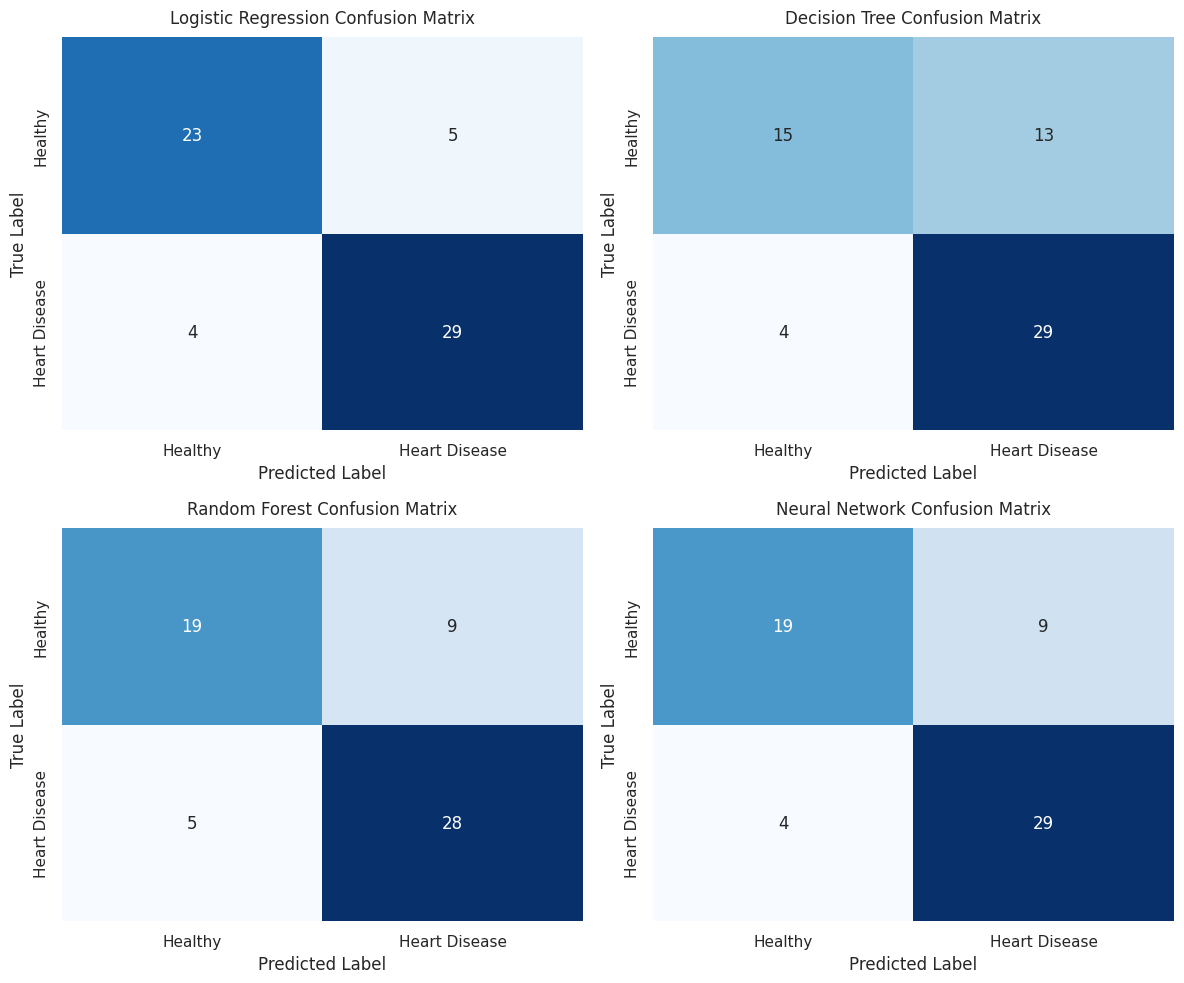

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

all_outputs = [('Logistic Regression', grid_log.best_estimator_.predict(X_test_processed)),('Decision Tree', grid_dt.best_estimator_.predict(X_test_processed)),('Random Forest', grid_rf.best_estimator_.predict(X_test_processed)),]

if 'Neural Network' in evaluation_results:
    all_outputs.append(('Neural Network', nn_predictions))

for idx, (name, preds) in enumerate(all_outputs):
    if idx < len(axes):
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                    xticklabels=['Healthy', 'Heart Disease'],
                    yticklabels=['Healthy', 'Heart Disease'])
        axes[idx].set_title(f'{name} Confusion Matrix', fontsize=12, pad=10)
        axes[idx].set_xlabel('Predicted Label')
        axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('model_confusion_matrices.png', dpi=300)
plt.show()